In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np

In [2]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
 
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


SEEDS SETUP

In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [4]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total
 


In [5]:
DATASET_NAME ='MNIST'
DATASET_CLASS = torchvision.datasets.MNIST
NORMALIZE_MEAN_STD = ((0.1307,),(0.3081))
SEEDS =[0,42,123]

In [6]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*NORMALIZE_MEAN_STD)
])
train_data = DATASET_CLASS(root='./data', train=True, download=True, transform=transform)
test_data  = DATASET_CLASS(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
 

#STEP-1: Train + save baseline for each seed

In [13]:
for seed in SEEDS:
    print(f"\n=== Training {DATASET_NAME} seed {seed} ===")
    set_seed(seed)
    train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
    model=TinyNet()
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        total_loss = 0 
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output,labels)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
    baseline_acc = evaluate(model,test_loader)
    print(f"  Seed {seed} baseline accuracy: {baseline_acc:.2f}%")
    
    fname = f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'
    torch.save(model.state_dict(), fname)
    print(f"  Saved: {fname}")

 



=== Training MNIST seed 0 ===
  Epoch 1 | Loss: 0.2477
  Epoch 2 | Loss: 0.0724
  Epoch 3 | Loss: 0.0549
  Epoch 4 | Loss: 0.0437
  Epoch 5 | Loss: 0.0347
  Seed 0 baseline accuracy: 98.60%
  Saved: tinynet_mnist_seed0.pth

=== Training MNIST seed 42 ===
  Epoch 1 | Loss: 0.2266
  Epoch 2 | Loss: 0.0694
  Epoch 3 | Loss: 0.0500
  Epoch 4 | Loss: 0.0407
  Epoch 5 | Loss: 0.0327
  Seed 42 baseline accuracy: 98.78%
  Saved: tinynet_mnist_seed42.pth

=== Training MNIST seed 123 ===
  Epoch 1 | Loss: 0.2196
  Epoch 2 | Loss: 0.0659
  Epoch 3 | Loss: 0.0470
  Epoch 4 | Loss: 0.0359
  Epoch 5 | Loss: 0.0299
  Seed 123 baseline accuracy: 98.72%
  Saved: tinynet_mnist_seed123.pth


#STEP-2: Sensitivity GAP sweep for each seed

In [8]:
def load_fresh_model(seed):
    model = TinyNet()
    model.load_state_dict(torch.load(f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'))
    model.eval()
    return model
 
def prune_single_layer(model, layer_name, amount):
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    return model
#CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
#CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60,
#               62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74,
#               75, 76, 77, 78, 79, 80, 82, 84, 86, 88, 90]
CHECKPOINTS_FINE = list(range(20, 91))
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
 
results = {}
per_layer_results = {}


 
for seed in SEEDS:
    print(f"\n=== Sensitivity sweep, {DATASET_NAME} seed {seed} ===")
    baseline_model = load_fresh_model(seed)
    baseline_acc = evaluate(baseline_model, test_loader)
 
    seed_gaps = {}
    per_layer_results[seed] ={}
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        layer_drops = {}
        for layer_name in LAYERS:
            m = load_fresh_model(seed)
            m = prune_single_layer(m, layer_name, amount)
            acc = evaluate(m, test_loader)
            drop = baseline_acc - acc
            layer_drops[layer_name] = drop
        per_layer_results[seed][pct] = layer_drops
        gap = max(layer_drops.values()) - min(layer_drops.values())
        seed_gaps[pct] = gap
        print(f"  {pct}% sparsity | gap = {gap:.2f}pp | drops = {layer_drops}")
 
    results[seed] = seed_gaps

 



=== Sensitivity sweep, MNIST seed 0 ===
  20% sparsity | gap = 0.09pp | drops = {'conv1': -0.0800000000000125, 'conv2': -0.04000000000000625, 'fc1': 0.009999999999990905, 'fc2': -0.030000000000001137}
  21% sparsity | gap = 0.04pp | drops = {'conv1': -0.04000000000000625, 'conv2': -0.020000000000010232, 'fc1': 0.0, 'fc2': -0.020000000000010232}
  22% sparsity | gap = 0.07pp | drops = {'conv1': -0.07000000000000739, 'conv2': -0.05000000000001137, 'fc1': 0.0, 'fc2': -0.030000000000001137}
  23% sparsity | gap = 0.03pp | drops = {'conv1': -0.04000000000000625, 'conv2': -0.020000000000010232, 'fc1': -0.020000000000010232, 'fc2': -0.05000000000001137}
  24% sparsity | gap = 0.02pp | drops = {'conv1': -0.04000000000000625, 'conv2': -0.05000000000001137, 'fc1': -0.030000000000001137, 'fc2': -0.04000000000000625}
  25% sparsity | gap = 0.05pp | drops = {'conv1': -0.030000000000001137, 'conv2': -0.020000000000010232, 'fc1': -0.04000000000000625, 'fc2': -0.07000000000000739}
  26% sparsity | ga

In [9]:
import json

with open('MNIST_gap_20_90.json', 'w') as f:
    json.dump({'results': results, 'per_layer_results': per_layer_results}, f)

print("Saved.")

Saved.


# Uniform Pruning

In [10]:
def prune_uniform(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(model.fc2,   name='weight', amount=amount)
    return model
 
uniform_results = {}
 
for seed in SEEDS:
    print(f"\n=== Uniform pruning sweep, {DATASET_NAME} seed {seed} ===")
    seed_accs = {}
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        m = load_fresh_model(seed)
        m = prune_uniform(m, amount)
        acc = evaluate(m, test_loader)
        seed_accs[pct] = acc
        print(f"  {pct}% sparsity | accuracy = {acc:.2f}%")
    uniform_results[seed] = seed_accs
 
print(f"\n\n=== SUMMARY: {DATASET_NAME} accuracy under uniform pruning, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{uniform_results[seed][pct]:>12.2f}", end="")
    print()


=== Uniform pruning sweep, MNIST seed 0 ===
  20% sparsity | accuracy = 98.66%
  21% sparsity | accuracy = 98.66%
  22% sparsity | accuracy = 98.58%
  23% sparsity | accuracy = 98.56%
  24% sparsity | accuracy = 98.52%
  25% sparsity | accuracy = 98.55%
  26% sparsity | accuracy = 98.61%
  27% sparsity | accuracy = 98.60%
  28% sparsity | accuracy = 98.68%
  29% sparsity | accuracy = 98.73%
  30% sparsity | accuracy = 98.71%
  31% sparsity | accuracy = 98.70%
  32% sparsity | accuracy = 98.68%
  33% sparsity | accuracy = 98.67%
  34% sparsity | accuracy = 98.57%
  35% sparsity | accuracy = 98.47%
  36% sparsity | accuracy = 98.40%
  37% sparsity | accuracy = 98.28%
  38% sparsity | accuracy = 98.24%
  39% sparsity | accuracy = 97.95%
  40% sparsity | accuracy = 97.89%
  41% sparsity | accuracy = 98.20%
  42% sparsity | accuracy = 98.16%
  43% sparsity | accuracy = 98.14%
  44% sparsity | accuracy = 97.71%
  45% sparsity | accuracy = 97.71%
  46% sparsity | accuracy = 97.75%
  47% spar

In [11]:
print(f"\n\n=== SUMMARY: {DATASET_NAME} gap by sparsity, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
 
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{results[seed][pct]:>12.2f}", end="")
    print()
 
import json
outname = f'{DATASET_NAME.lower()}_multiseed_results.json'
with open(outname, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved: {outname}")



=== SUMMARY: MNIST gap by sparsity, across seeds ===
  Sparsity       seed0      seed42     seed123
       20%        0.09        0.03        0.06
       21%        0.04        0.02        0.09
       22%        0.07        0.03        0.08
       23%        0.03        0.11        0.11
       24%        0.02        0.12        0.11
       25%        0.05        0.14        0.10
       26%        0.12        0.13        0.19
       27%        0.11        0.14        0.22
       28%        0.07        0.03        0.17
       29%        0.06        0.11        0.19
       30%        0.04        0.09        0.20
       31%        0.05        0.08        0.15
       32%        0.01        0.07        0.02
       33%        0.06        0.05        0.07
       34%        0.08        0.03        0.04
       35%        0.13        0.10        0.05
       36%        0.12        0.15        0.11
       37%        0.13        0.16        0.19
       38%        0.18        0.17        0.17
     

# GRAPH

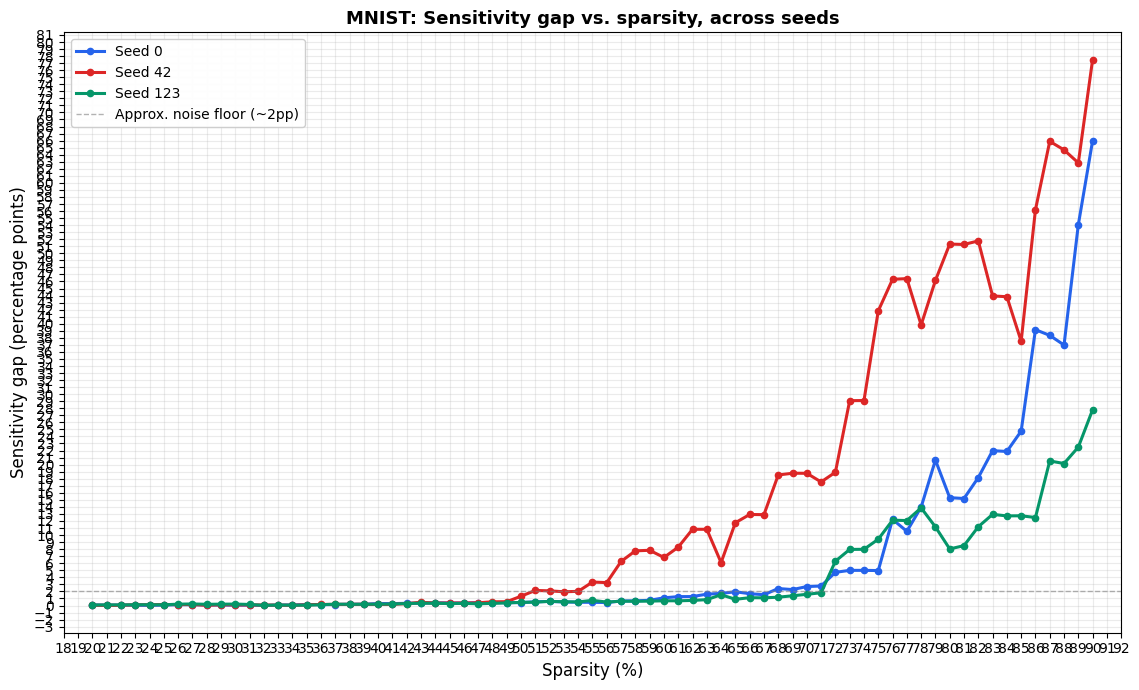

Saved: mnist_gap_multiseed.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator 

fig, ax = plt.subplots(figsize=(11.5, 7))
 
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}
 
for seed in SEEDS:
    gaps = [results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, gaps, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Approx. noise floor (~2pp)')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Sensitivity gap (percentage points)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Sensitivity gap vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(1))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(1)) 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_gap_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_gap_multiseed.png")

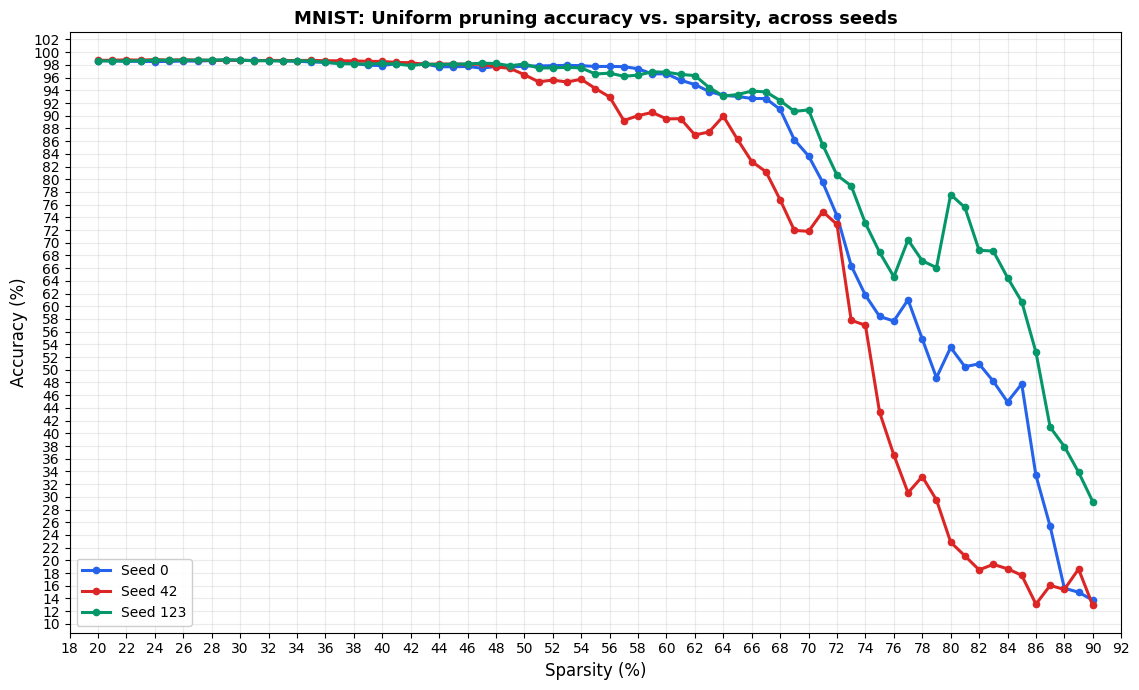

Saved: mnist_uniform_accuracy_multiseed.png


In [13]:
from matplotlib.ticker import MultipleLocator 

# GRAPH 2 — Accuracy vs sparsity (uniform pruning), across seeds


fig, ax = plt.subplots(figsize=(11.5, 7))
 
for seed in SEEDS:
    accs = [uniform_results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, accs, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Uniform pruning accuracy vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(2))   
ax.yaxis.set_major_locator(MultipleLocator(2)) 
 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_uniform_accuracy_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_uniform_accuracy_multiseed.png")

# Change Point Detection + Graph


Seed 0 — GAP change point
  Change point at sparsity ≈ 74%

Seed 0 — ACCURACY change point
  Change point at sparsity ≈ 74%
  --> Seed 0 lead time: 0pp


Seed 42 — GAP change point
  Change point at sparsity ≈ 64%
  Change point at sparsity ≈ 74%

Seed 42 — ACCURACY change point
  Change point at sparsity ≈ 64%
  Change point at sparsity ≈ 74%
  --> Seed 42 lead time: 0pp


Seed 123 — GAP change point
  Change point at sparsity ≈ 74%

Seed 123 — ACCURACY change point
  Change point at sparsity ≈ 74%
  --> Seed 123 lead time: 0pp



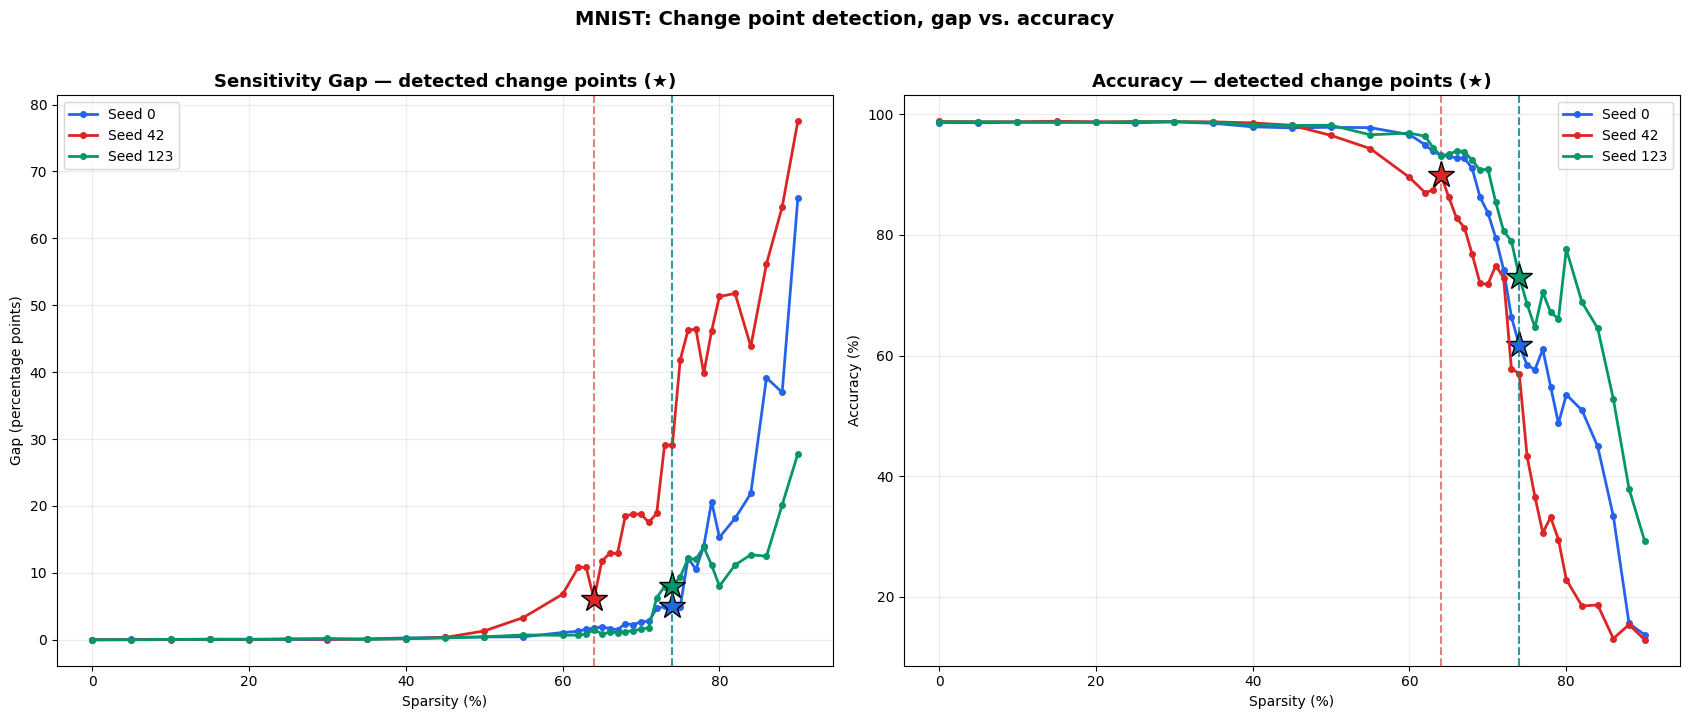


=== SUMMARY: lead times from change point detection ===
Seed 0: 0pp lead
Seed 42: 0pp lead
Seed 123: 0pp lead


In [ ]:

import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

def find_change_point(sparsity_values, signal_values, label=""):
    signal = np.array(signal_values)
    algo = rpt.Pelt(model="rbf").fit(signal)
    change_points = algo.predict(pen=3)
    real_points = [cp for cp in change_points if cp < len(signal)]

    print(f"\n{label}")
    if not real_points:
        print("  No significant change point detected")
        return None

    for cp_idx in real_points:
        print(f"  Change point at sparsity ≈ {sparsity_values[cp_idx]}%")

    return sparsity_values[real_points[0]]  # first detected change point



colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
ax_gap, ax_acc = axes

lead_times = {}

for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]

    gap_cp = find_change_point(CHECKPOINTS, gap_values, label=f"Seed {seed} — GAP change point")
    acc_cp = find_change_point(CHECKPOINTS, acc_values, label=f"Seed {seed} — ACCURACY change point")

    if gap_cp is not None and acc_cp is not None:
        lead = acc_cp - gap_cp
        lead_times[seed] = lead
        print(f"  --> Seed {seed} lead time: {lead}pp\n")

    color = colors[seed]

    ax_gap.plot(CHECKPOINTS, gap_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if gap_cp is not None:
        ax_gap.axvline(gap_cp, color=color, linestyle='--', alpha=0.6)
        ax_gap.plot(gap_cp, gap_values[CHECKPOINTS.index(gap_cp)], '*', color=color, markersize=20, markeredgecolor='black')

    ax_acc.plot(CHECKPOINTS, acc_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if acc_cp is not None:
        ax_acc.axvline(acc_cp, color=color, linestyle='--', alpha=0.6)
        ax_acc.plot(acc_cp, acc_values[CHECKPOINTS.index(acc_cp)], '*', color=color, markersize=20, markeredgecolor='black')

ax_gap.set_title('Sensitivity Gap — detected change points (★)', fontsize=13, fontweight='bold')
ax_gap.set_xlabel('Sparsity (%)')
ax_gap.set_ylabel('Gap (percentage points)')
ax_gap.legend()
ax_gap.grid(True, alpha=0.25)

ax_acc.set_title('Accuracy — detected change points (★)', fontsize=13, fontweight='bold')
ax_acc.set_xlabel('Sparsity (%)')
ax_acc.set_ylabel('Accuracy (%)')
ax_acc.legend()
ax_acc.grid(True, alpha=0.25)

plt.suptitle('MNIST: Change point detection, gap vs. accuracy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mnist_changepoint.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== SUMMARY: lead times from change point detection ===")
for seed, lead in lead_times.items():
    print(f"Seed {seed}: {lead}pp lead")

# PER-LAYER ANALYSIS
(to be done)

In [14]:
import json

with open('MNIST_gap_20_90.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # keys are strings (JSON does this) — seed and pct both

# Count how often each layer is the max-drop (most sensitive) layer, per seed
layer_win_counts = {}

for seed_str, checkpoints in per_layer.items():
    layer_win_counts[seed_str] = {'conv1': 0, 'conv2': 0, 'fc1': 0, 'fc2': 0}
    for pct_str, drops in checkpoints.items():
        max_layer = max(drops, key=drops.get)
        layer_win_counts[seed_str][max_layer] += 1

print("=== How often each layer is the most-sensitive one, out of 21 checkpoints ===")
for seed_str, counts in layer_win_counts.items():
    print(f"Seed {seed_str}: {counts}")

print("\n=== Dominant layer at every single checkpoint (to spot flips) ===")
for seed_str, checkpoints in per_layer.items():
    print(f"\nSeed {seed_str}:")
    for pct_str in sorted(checkpoints, key=lambda x: int(x)):
        drops = checkpoints[pct_str]
        max_layer = max(drops, key=drops.get)
        print(f"  {pct_str}% -> {max_layer} (drop={drops[max_layer]:.2f})")

=== How often each layer is the most-sensitive one, out of 21 checkpoints ===
Seed 0: {'conv1': 20, 'conv2': 4, 'fc1': 6, 'fc2': 41}
Seed 42: {'conv1': 43, 'conv2': 5, 'fc1': 0, 'fc2': 23}
Seed 123: {'conv1': 27, 'conv2': 31, 'fc1': 0, 'fc2': 13}

=== Dominant layer at every single checkpoint (to spot flips) ===

Seed 0:
  20% -> fc1 (drop=0.01)
  21% -> fc1 (drop=0.00)
  22% -> fc1 (drop=0.00)
  23% -> conv2 (drop=-0.02)
  24% -> fc1 (drop=-0.03)
  25% -> conv2 (drop=-0.02)
  26% -> conv1 (drop=0.07)
  27% -> conv1 (drop=0.07)
  28% -> conv1 (drop=0.02)
  29% -> fc1 (drop=0.00)
  30% -> fc1 (drop=-0.01)
  31% -> fc2 (drop=0.00)
  32% -> conv1 (drop=-0.02)
  33% -> fc2 (drop=0.01)
  34% -> fc2 (drop=0.03)
  35% -> fc2 (drop=0.08)
  36% -> fc2 (drop=0.09)
  37% -> fc2 (drop=0.10)
  38% -> fc2 (drop=0.16)
  39% -> fc2 (drop=0.15)
  40% -> fc2 (drop=0.23)
  41% -> fc2 (drop=0.21)
  42% -> fc2 (drop=0.25)
  43% -> fc2 (drop=0.26)
  44% -> fc2 (drop=0.30)
  45% -> fc2 (drop=0.29)
  46% -> f

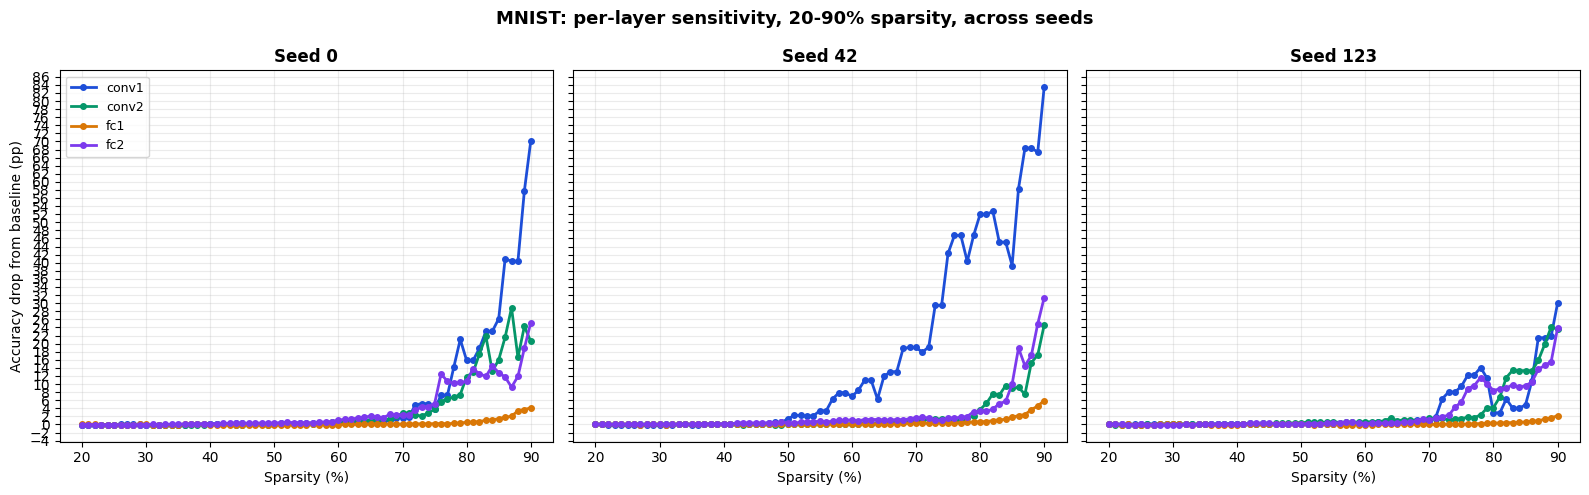

Saved: KMNIST_layer_analysis_20_90.png


In [15]:
import json
import matplotlib.pyplot as plt

with open('MNIST_gap_20_90.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # seed -> pct -> {layer: drop}, all keys are strings after JSON reload

layer_colors = {'conv1': '#1D4ED8', 'conv2': '#059669', 'fc1': '#D97706', 'fc2': '#7C3AED'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, seed in zip(axes, SEEDS):
    seed_str = str(seed)
    checkpoints = sorted(per_layer[seed_str].keys(), key=lambda x: int(x))
    sparsities = [int(pct) for pct in checkpoints]

    for layer_name, color in layer_colors.items():
        drops = [per_layer[seed_str][pct][layer_name] for pct in checkpoints]
        ax.plot(sparsities, drops, '-o', color=color, linewidth=2, markersize=4, label=layer_name)

    ax.set_title(f'Seed {seed}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sparsity (%)')
    ax.grid(True, alpha=0.25)
   
ax.yaxis.set_major_locator(MultipleLocator(2))
axes[0].set_ylabel('Accuracy drop from baseline (pp)')
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle('MNIST: per-layer sensitivity, 20-90% sparsity, across seeds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('MNIST_layer_analysis_20_90.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: KMNIST_layer_analysis_20_90.png")

In [16]:
import json
with open('mnist_full_sweep.json', 'w') as f:
    json.dump({'results': results, 'per_layer_results': per_layer_results, 'uniform_results': uniform_results}, f)
print("Saved.")

Saved.
